# 1D diffusion equation
Solution of the 1D diffusion equation using:
1. Explicit method
2. Implicit method
    - ~Thomas Algorithm~
    - Matrix Inversion
    - Iterative methods (Jacobi, Gauss-Seidel): Next class

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
N_x = 20
timesteps = 500
dx = 1.0
dt = 0.2
Diffusivity = 1.0

In [5]:
x_array = np.arange(0, N_x, dx)

## Dirichlet Boundary Conditions

In [19]:
def initialize(c):
    c[0] = 1.0
    c[-1] = 0.0
    return

def apply_BC_Dirichlet(c):
    # Dirichlet (fixed) boundary condition
    c[0] = 1.0
    c[N_x-1] = 0.0
    return

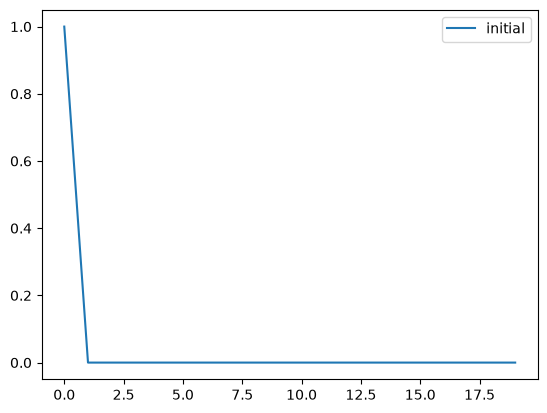

In [22]:
c_exp = np.zeros(N_x)
initialize(c_exp)

# plotting initial profile
plt.plot(x_array, c_exp, label='initial')
plt.legend()
plt.show()

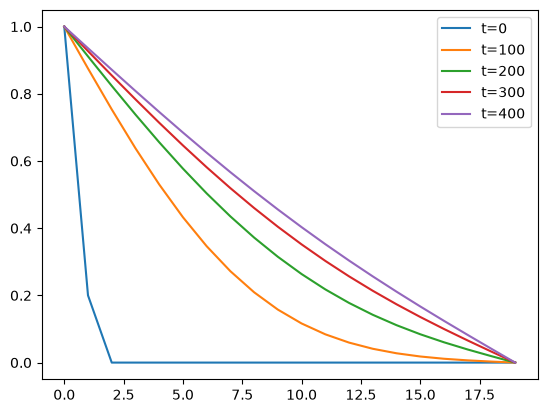

In [23]:
# explicit solution
c_exp_new = np.zeros(N_x)
for t in range(timesteps):
    for i in range(1, N_x-1): # exclude the first and last point
        dc_dt = Diffusivity*( c_exp[i-1] - 2*c_exp[i] + c_exp[i+1] )/(dx**2)
        c_exp_new[i] = c_exp[i] + dc_dt*dt
    apply_BC_Dirichlet(c_exp_new) # apply boundary condition at each time step
    # apply_BC_Neumann(c_exp_new)
    c_exp = np.copy(c_exp_new) # copying updated values to c_exp
    if t%100 == 0: 
        plt.plot(x_array, c_exp, label='t=' + str(t))
plt.legend()
plt.show()

## Neumann Boundary Conditions

In [31]:
def initialize_centre(c):
    c[N_x//2] = 1.0
    return
def apply_BC_Neumann(c):
    # Neumann (zero flux) boundary condition
    c[0] = c[1] # not the reverse
    c[N_x-1] = c[N_x-2] # not the reverse
    return

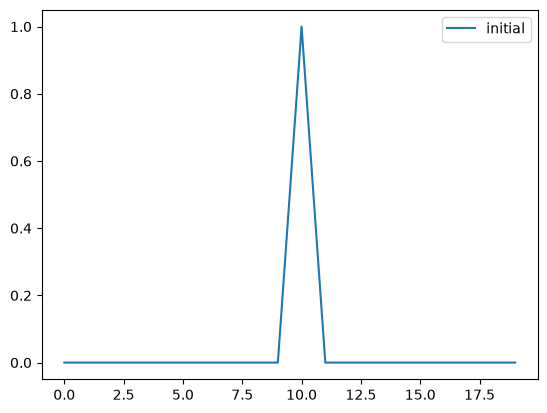

In [32]:
c_exp = np.zeros(N_x)
initialize_centre(c_exp)
apply_BC_Neumann(c_exp_new)
# plotting initial profile
plt.plot(x_array, c_exp, label='initial')
plt.legend()
plt.show()

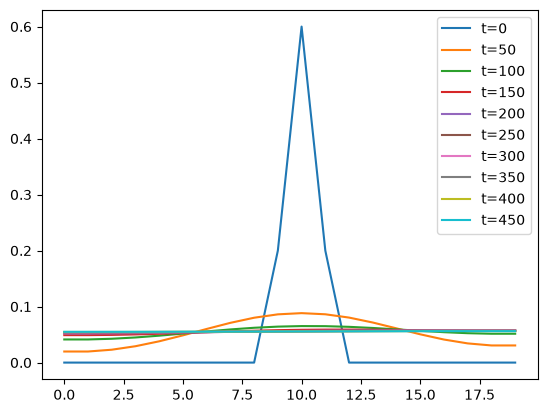

In [33]:
# explicit solution
c_exp_new = np.zeros(N_x)
for t in range(timesteps):
    for i in range(1, N_x-1): # exclude the first and last point
        dc_dt = Diffusivity*( c_exp[i-1] - 2*c_exp[i] + c_exp[i+1] )/(dx**2)
        c_exp_new[i] = c_exp[i] + dc_dt*dt
    # apply boundary condition at each time step
    apply_BC_Neumann(c_exp_new)
    c_exp = np.copy(c_exp_new) # copying updated values to c_exp
    if t%50 == 0: 
        plt.plot(x_array, c_exp, label='t=' + str(t))
plt.legend()
plt.show()

## Questions 
1. In which case is mass inside the domain getting conserved?
1. What happens with an increase in $\Delta t$?

## Implement Periodic BCs

In [44]:
def initialize_sin(c):
    c[:] = np.sin(2 * np.pi * x_array / (dx * (N_x - 1)))
    return
def apply_BC_periodic(c):

    return

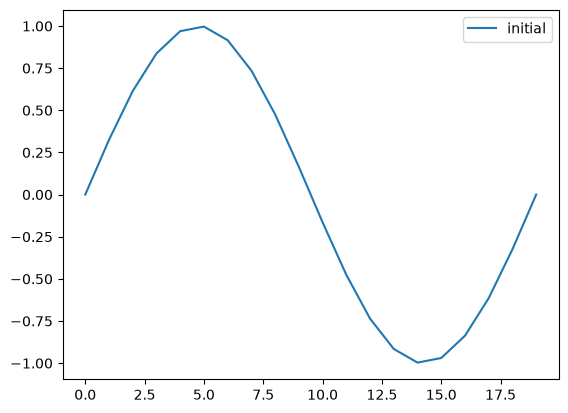

In [45]:
c_exp = np.zeros(N_x)
initialize_sin(c_exp)

# plotting initial profile
plt.plot(x_array, c_exp, label='initial')
plt.legend()
plt.show()

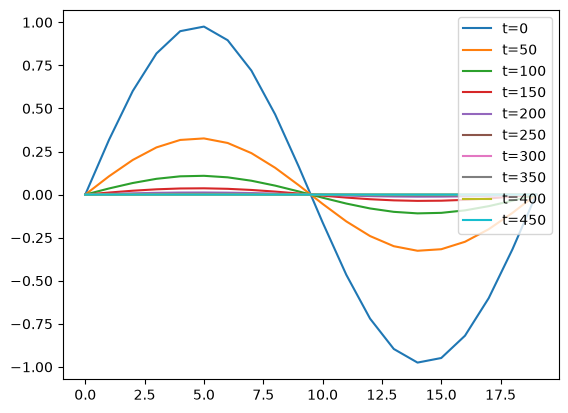

In [46]:
# explicit solution
c_exp_new = np.zeros(N_x)
for t in range(timesteps):
    for i in range(1, N_x-1): 
        dc_dt = Diffusivity*( c_exp[i-1] - 2*c_exp[i] + c_exp[i+1] )/(dx**2)
        c_exp_new[i] = c_exp[i] + dc_dt*dt
    # apply boundary condition at each time step
    apply_BC_periodic(c_exp_new)
    c_exp = np.copy(c_exp_new) # copying updated values to c_exp
    if t%50 == 0: 
        plt.plot(x_array, c_exp, label='t=' + str(t))
plt.legend()
plt.show()

## Implicit expression:
### Backward Time Centred Space (BTCS):
$$ \frac{\partial c}{\partial t} = D \frac{\partial^2 c}{\partial x^2} $$

$$ \frac{c^{t+1}_i - c^t_i}{\Delta t} = D \frac{ c^{t+1}_{i+1} - 2c^{t+1}_{i} + c^{t+1}_{i-1} }{{\Delta x}^2}$$
Let $ \alpha = \frac{D{\Delta t}}{{\Delta x}^2}$,
$$ -\alpha c_{i-1}^{t+1} + (1 + 2\alpha )c_i^{t+1} -\alpha c_{i+1}^{t+1} = c_i^t $$

In simpler terms,
$$ A_i c_{i-1}^{t+1} + B_i c_i^{t+1} + C_i c_{i+1}^{t+1} = D_i $$

### Implicit solution using Matrix Inversion (Dirichlet BC)

 Applying Dirichlet boundary conditions, The values $c_0^{t+1}$ and $c_{N_x-1}^{t+1}$ are known boundary conditions. 
 
 We are solving for the internal nodes: $i = 1, 2, \dots, N_x-2$. 
 
 1. The Matrix of system of equations $ax = b$ for the unknown interior nodes looks like this: 

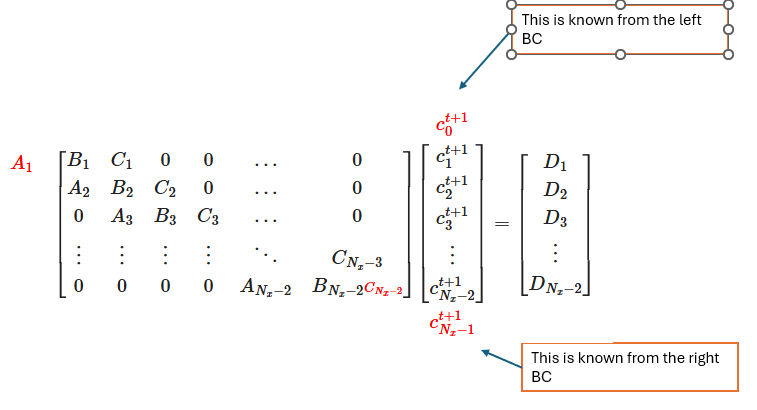

$$
\begin{array}{cc}
\begin{matrix} \color{red}{A_1} \\ \phantom{A_2} \\ \phantom{0} \\ \phantom{\vdots} \\ \phantom{0} \end{matrix}
&
\begin{bmatrix}
B_1 & C_1 & 0 & 0 & \dots & 0 \\
A_2 & B_2 & C_2 & 0 & \dots & 0 \\
0 & A_3 & B_3 & C_3 & \dots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & C_{N_x-3} \\
0 & 0 & 0 & 0 & A_{N_x-2} & B_{N_x-2} \color{red}{\scriptstyle C_{N_x-2}}
\end{bmatrix}
\begin{matrix}
\color{red}{c_0^{t+1}} \\
\begin{bmatrix}
c_1^{t+1} \\
c_2^{t+1} \\
c_3^{t+1} \\
\vdots \\
c_{N_x-2}^{t+1}
\end{bmatrix} \\
\color{red}{c_{N_x-1}^{t+1}}
\end{matrix}
=
\begin{bmatrix}
D_1 \\
D_2 \\
D_3 \\
\vdots \\
D_{N_x-2}
\end{bmatrix}
\end{array}
$$

If we move the known BCs in the constant D, this can be simplified to:
$$\begin{bmatrix} 
B_1 & C_1 & 0 & 0 & \dots & 0 \\
A_2 & B_2 & C_2 & 0 & \dots & 0 \\
0 & A_3 & B_3 & C_3 & \dots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & C_{N_x-3} \\
0 & 0 & 0 & 0 & A_{N_x-2} & B_{N_x-2} 
\end{bmatrix}
\begin{bmatrix} 
c_1^{t+1} \\
c_2^{t+1} \\
c_3^{t+1} \\
\vdots \\
c_{N_x-2}^{t+1}
\end{bmatrix}
=
\begin{bmatrix} 
D_1' \\
D_2 \\
D_3 \\
\vdots \\
D'_{N_x-2}
\end{bmatrix}$$

Where 
$$D'_1 = D_1 - A_1*c_0^{t+1}$$ and 
$$D'_{N_x-2} = D_{N_x-2} - A_{N_x-2}*c_{N_x-1}^{t+1}$$

For $i \in [1, N_x-2]$:

$$A_i = -\alpha$$ 
$$B_i = 1 + 2\alpha$$ 
$$C_i = -\alpha$$
$$D_i = c_i^t$$
And corner points:
$$D'_1 = c_1^t + \alpha c_0^{t+1}$$
$$D'_{N_x-2} = c_{N_x-2}^t + \alpha c_{N_x-1}^{t+1}$$

In [52]:
np.diag((1 + 2 * alpha) * np.ones(5))

array([[1.4, 0. , 0. , 0. , 0. ],
       [0. , 1.4, 0. , 0. , 0. ],
       [0. , 0. , 1.4, 0. , 0. ],
       [0. , 0. , 0. , 1.4, 0. ],
       [0. , 0. , 0. , 0. , 1.4]])

In [56]:
np.diag((-alpha) * np.ones(5-1), -1)

array([[ 0. ,  0. ,  0. ,  0. ,  0. ],
       [-0.2,  0. ,  0. ,  0. ,  0. ],
       [ 0. , -0.2,  0. ,  0. ,  0. ],
       [ 0. ,  0. , -0.2,  0. ,  0. ],
       [ 0. ,  0. ,  0. , -0.2,  0. ]])

In [58]:
np.diag((1 + 2 * alpha) * np.ones(5)) + np.diag((-alpha) * np.ones(5-1), -1)

array([[ 1.4,  0. ,  0. ,  0. ,  0. ],
       [-0.2,  1.4,  0. ,  0. ,  0. ],
       [ 0. , -0.2,  1.4,  0. ,  0. ],
       [ 0. ,  0. , -0.2,  1.4,  0. ],
       [ 0. ,  0. ,  0. , -0.2,  1.4]])

In [53]:
N_x = 20
timesteps = 500
dx = 1.0
dt = 0.2
Diffusivity = 1.0

x_array = np.arange(0, N_x, dx)
alpha = Diffusivity * dt / (dx**2)

# Initial conditions
c_mat = np.zeros(N_x)
apply_BC_Dirichlet(c_mat)

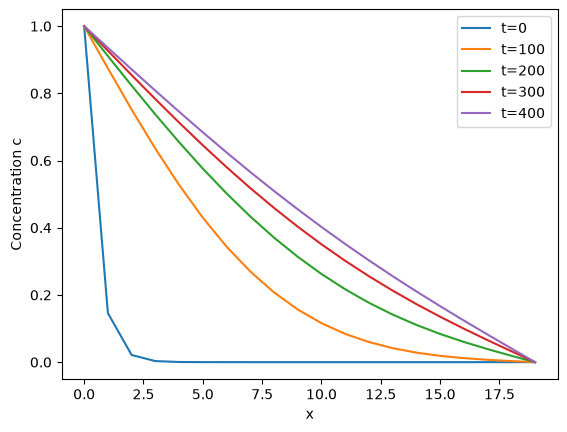

In [54]:
# Construct matrix A for interior nodes: i = 1, 2, ..., N_x - 2
# Main diagonal = (1 + 2*alpha), sub-diagonals = -alpha
a = np.diag((1 + 2 * alpha) * np.ones(N_x-2)) \
  + np.diag(-alpha * np.ones(N_x - 3), k=-1) \
  + np.diag(-alpha * np.ones(N_x - 3), k=1)

a_inv = np.linalg.inv(a)

# Time stepping loop
for t in range(timesteps):
    # RHS vector b = current solution c[1:N_x-1]
    b = c_mat[1:-1].copy()
    
    # Add Dirichlet boundary condition contributions
    b[0] += alpha * c_mat[0]     # Left boundary contribution c[0]
    b[-1] += alpha * c_mat[-1]   # Right boundary contribution c[N_x-1]
    
    # Direct solution: x = a^(-1) * b
    c_mat[1:-1] = np.dot(a_inv, b)
    
    if t % 100 == 0:
        plt.plot(x_array, c_mat, label=f't={t}')

plt.xlabel('x')
plt.ylabel('Concentration c')
plt.legend()
plt.show()

### Implicit solution using Thomas Algorithm (Tridiagonal Matrix Algorithm): Will not be covered in this course

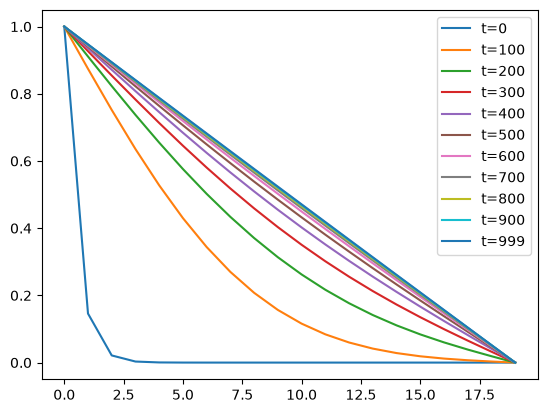

In [79]:
N_x = 20
timesteps = 1000
dx = 1.0
dt = 0.2
Diffusivity = 1.0
x_array = np.arange(0, N_x, dx)

c_jac = np.zeros(N_x)
A = np.zeros(N_x)
B = np.zeros(N_x)
C = np.zeros(N_x)
D = np.zeros(N_x)

# c_jac[N_x//2] = 1.0 # initialization
initialize(c_jac)
apply_BC(c_jac)
c_jac_new = np.copy(c_jac)
alpha = Diffusivity*dt/(dx**2)
total_iterations = 10 # total number of iterations
for t in range(timesteps):
    A[1:N_x-1] = -alpha
    B[1:N_x-1] = (1 + 2*alpha)
    C[1:N_x-1] = -alpha
    D[1:N_x-1] = c_jac[1:N_x-1]
    
    for iterations in range(total_iterations):
        for i in range(1, N_x-1):
            c_jac_new[i] = (D[i] - A[i]*c_jac[i-1] - C[i]*c_jac[i+1])/B[i]
        apply_BC(c_jac_new)
        # update c_jac each iteration
        c_jac = np.copy(c_jac_new)
    if t%100 == 0: 
        plt.plot(x_array, c_jac, label='t=' + str(t))
plt.plot(x_array, c_exp, label='t=' + str(t))

plt.legend()
plt.show()

In [85]:
np.diag((1 + 2 * alpha) * np.ones(5))

array([[1.4, 0. , 0. , 0. , 0. ],
       [0. , 1.4, 0. , 0. , 0. ],
       [0. , 0. , 1.4, 0. , 0. ],
       [0. , 0. , 0. , 1.4, 0. ],
       [0. , 0. , 0. , 0. , 1.4]])

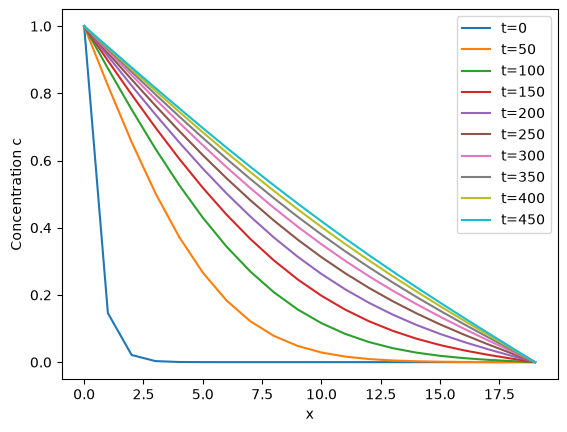

In [61]:
N_x = 20
timesteps = 500
dx = 1.0
dt = 0.2
Diffusivity = 1.0

x_array = np.arange(0, N_x, dx)
alpha = Diffusivity * dt / (dx**2)

# Initial conditions
c_mat = np.zeros(N_x)
c_mat[0] = 1.0       # Dirichlet BC at left boundary
c_mat[-1] = 0.0      # Dirichlet BC at right boundary

# Construct matrix A for interior nodes: i = 1, 2, ..., N_x - 2
# Main diagonal = (1 + 2*alpha), sub-diagonals = -alpha
a = np.diag((1 + 2 * alpha) * np.ones(N_x-2)) \
  + np.diag(-alpha * np.ones(N_x - 3), k=-1) \
  + np.diag(-alpha * np.ones(N_x - 3), k=1)

a_inv = np.linalg.inv(a)

# Time stepping loop
for t in range(timesteps):
    # RHS vector b = current solution c[1:N_x-1]
    b = c_mat[1:-1].copy()
    
    # Add Dirichlet boundary condition contributions
    b[0] += alpha * c_mat[0]     # Left boundary contribution c[0]
    b[-1] += alpha * c_mat[-1]   # Right boundary contribution c[N_x-1]
    
    # Direct solution: x = a^(-1) * b
    c_mat[1:-1] = np.dot(a_inv, b)
    
    if t % 50 == 0:
        plt.plot(x_array, c_mat, label=f't={t}')

plt.xlabel('x')
plt.ylabel('Concentration c')
plt.legend()
plt.show()

## Question: Implement Neumann BC using the implicit matrix form with initial condition as a spike in the centre?